In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

In [2]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    'ESP Vibration X',
    'ESP Vibration Y',
    #'ESP Power',
    #"Well_down"
    ]

/tmp/ipykernel_87347/1698806942.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [3]:
# totalData[Headers].loc[totalData["Well_down"]==0].apply(np.log1p).hist(figsize=(20,20),bins=200)

In [4]:
mainSeed = 971215
np.random.seed(mainSeed)

PCAHeaders = [str(i) for i in range(0,7)]

pumpList = totalData["Well Run"].unique()

#complexVib = totalData["ESP Vibration X"]+1j*totalData["ESP Vibration Y"]

#totalData["VibMod"] = np.absolute(complexVib)
#totalData["VibArc"] = np.unwrap(np.angle(complexVib))
totalData["Choke Closed"] = 1-totalData["Choke Opening"]
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

GMM BIC: 3114622.336212627


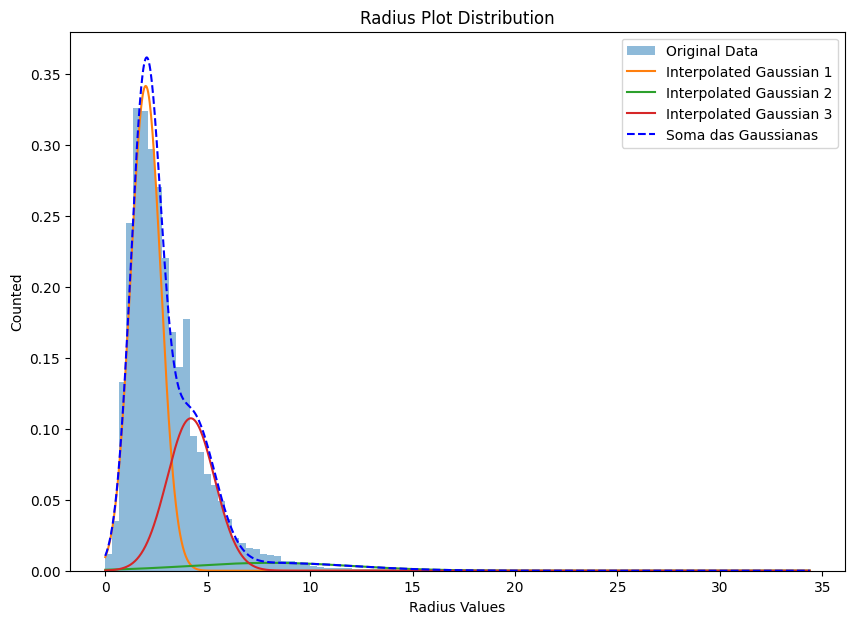

(GaussianMixture(n_components=3, random_state=971215),
 <Figure size 1000x700 with 1 Axes>)

In [5]:
n = 3
radiusData = totalData["Radius"].loc[totalData["Well_down"]==0]

model = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)


li.GaussianMixturePlot(radiusData,model,[
    "Original Data",
    "Interpolated Gaussian",
    "Radius Plot Distribution",
    "Radius Values",
    "Counted"],
    figsize=(10,7))

# n = 2

# model = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)


# li.GaussianMixturePlot(radiusData,model,[
#     "Original Data",
#     "Interpolated Gaussian",
#     "Radius Plot Distribution",
#     "Radius Values",
#     "Counted"],
#     figsize=(10,7))



In [6]:
modelRadius = hmm.GaussianHMM(
    n_components=n,
    random_state=mainSeed,
    covariance_type="full",
    init_params="st",
    algorithm="map"
    )

modelRadius.means_ = model.means_
modelRadius.covars__ = model.covariances_


modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)

li.PostProcessing(modelRadius, totalData, modelData,"Radius", "State Radius", totalLength)
print(modelRadius.get_stationary_distribution())
totalData["State Radius"] = totalData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))



AIC: 1861726.6025321241 BIC: 1861889.7005840288
[0.24987095 0.07438273 0.67574631]


In [7]:
vibeHeader = ["ESP Vibration X","ESP Vibration Y"]
esotericHeader = ['Water Cut @ 20degC - 1 atm', 'Choke Opening']

n = [2]

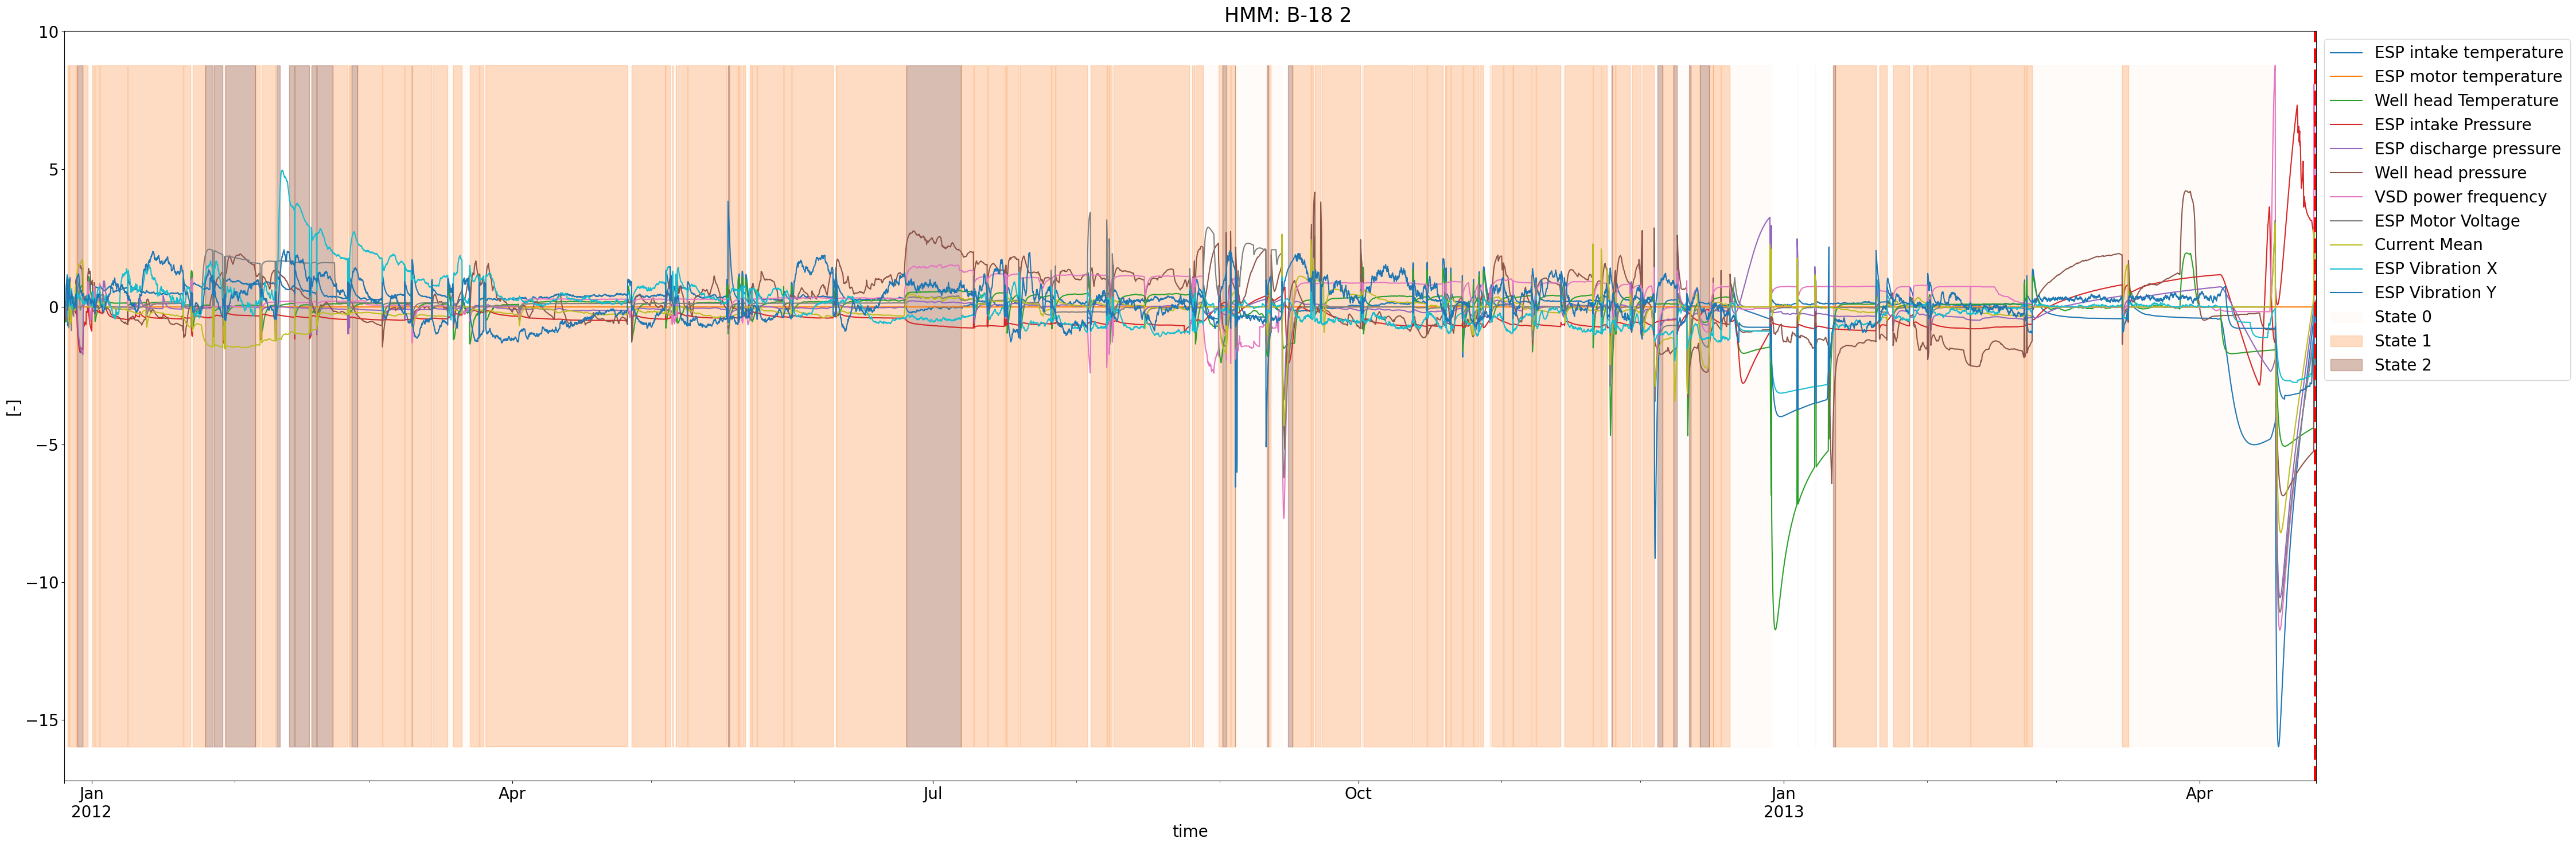

In [8]:
pump = pumpList[0]
pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
fig,axs = li.HMMPicture(pumpData,pump,props=[Headers],measures='[-]',states=["State Radius"], numberOfStates=n, figsize=(45,15))
plt.rcParams["font.size"]=20

fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")


KeyboardInterrupt: 

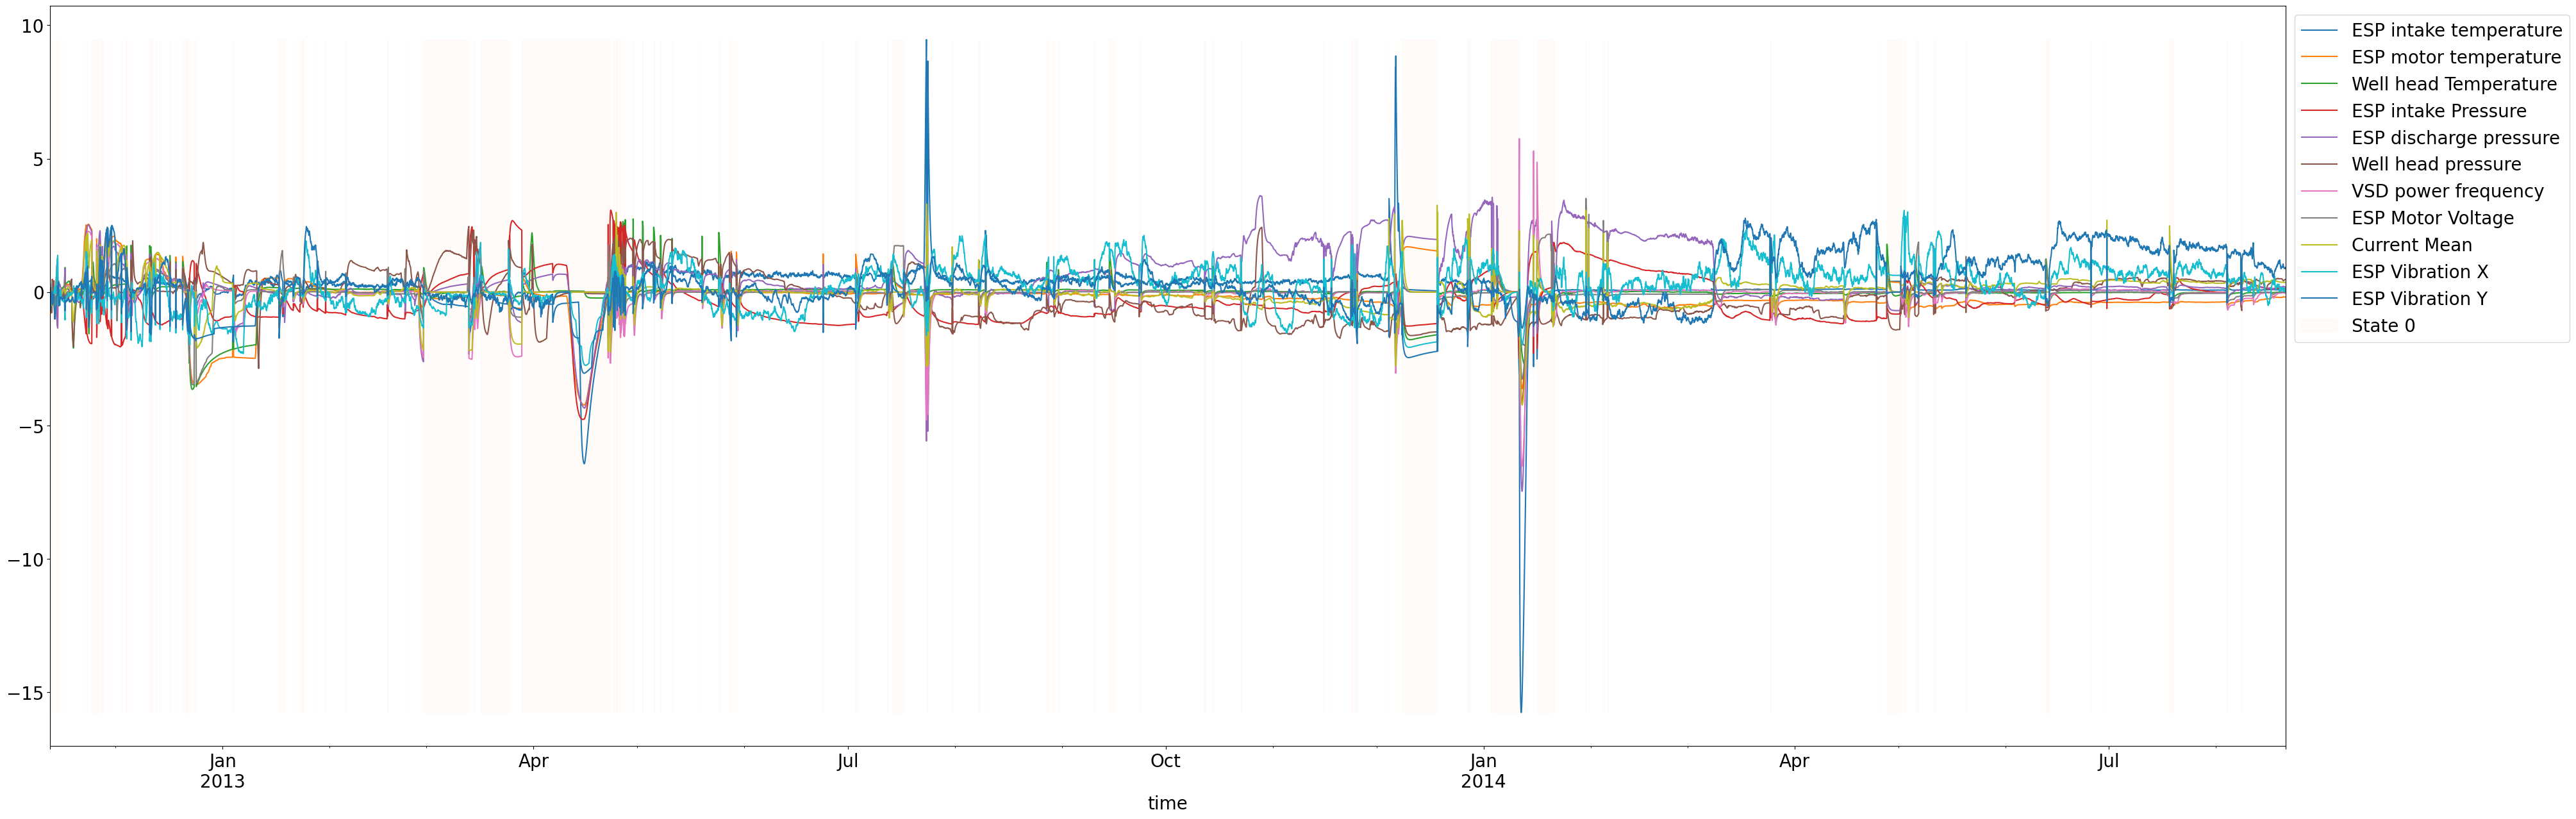

In [9]:
for pump in pumpList:
    pumpData = totalData.loc[totalData["Well Run"]==pump].copy()
    fig,axs = li.HMMPicture(pumpData,pump,props=[Headers],measures='[-]',states=["State Radius"], numberOfStates=n, figsize=(45,15))
    plt.rcParams["font.size"]=20

    fig.savefig("../imagens_gerais/pumps/"+pump+"markovrun.jpg")
    plt.close()

In [ ]:
medianListR = np.array([])

for pump in pumpList:
    pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
    last = pumpData.shape[0]
    pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
    medianListR = np.append(medianListR,pumpMedianR)




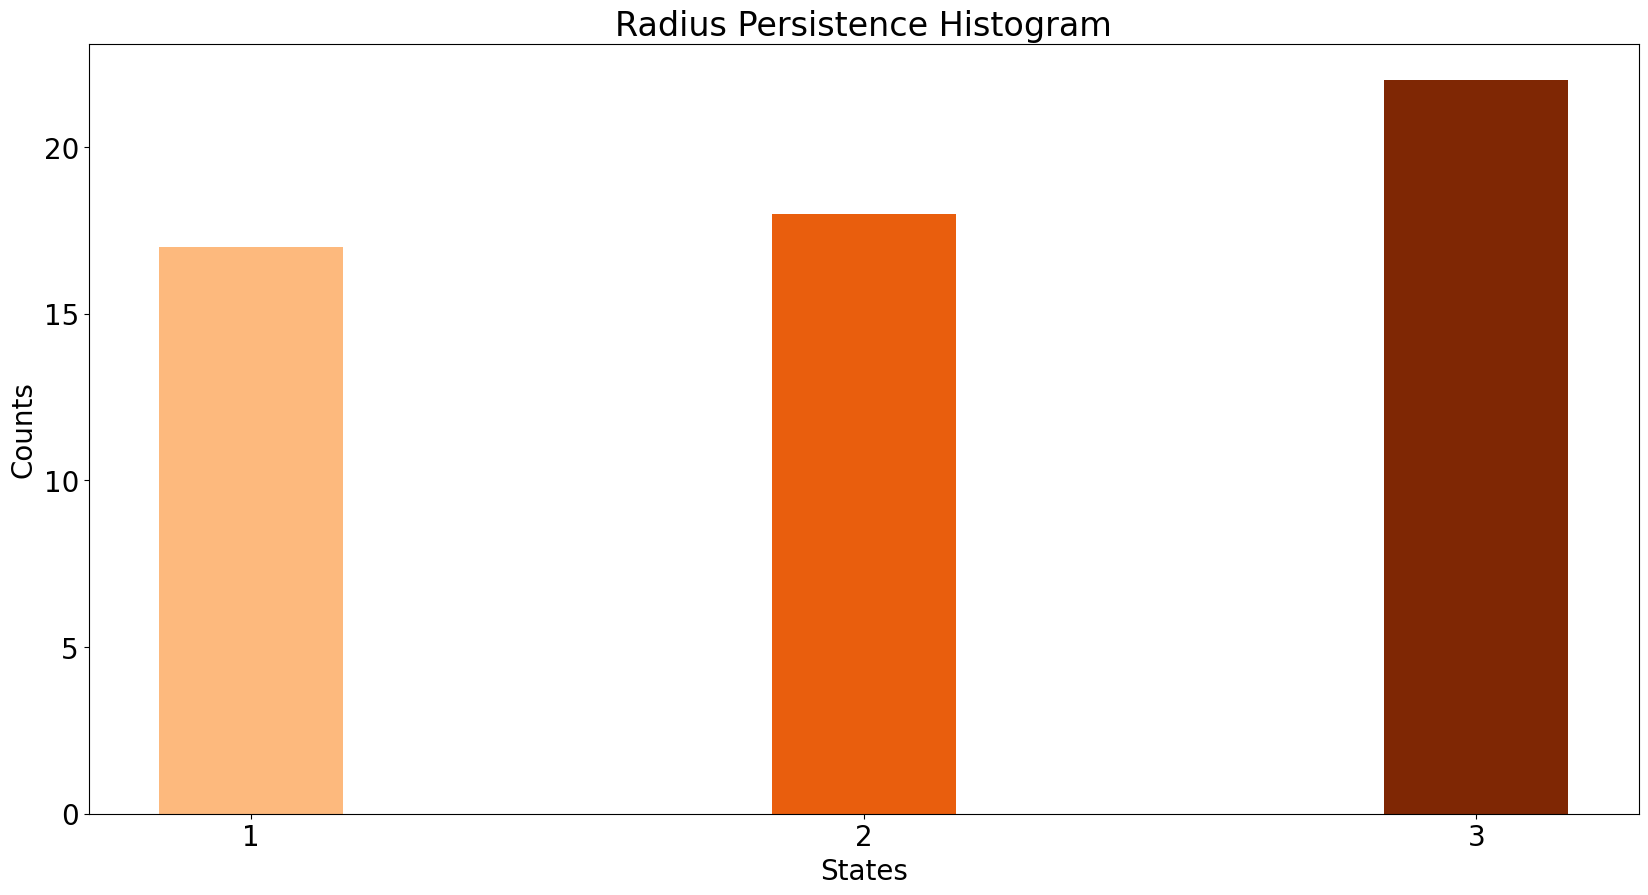

In [ ]:
cmap = plt.get_cmap('Oranges', n[0]+1)
fig,axs=plt.subplots(1,1,figsize=(20,10))
states,counts = np.unique(medianListR,return_counts=True)
axs.bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs.set_xticks(states,np.int64(states))
axs.set_ylabel("Counts")
axs.set_xlabel("States")
axs.set_title("Radius Persistence Histogram")


plt.savefig("../imagens_gerais/radius_histogram.jpg")

In [ ]:
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1]]) # Substituir pelos valores reais
expected_counts = np.array([1/2, 1/2]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 7.7368, p-valor: 0.0054
Rejeitamos H0: C ocorre significativamente mais do que o esperado.


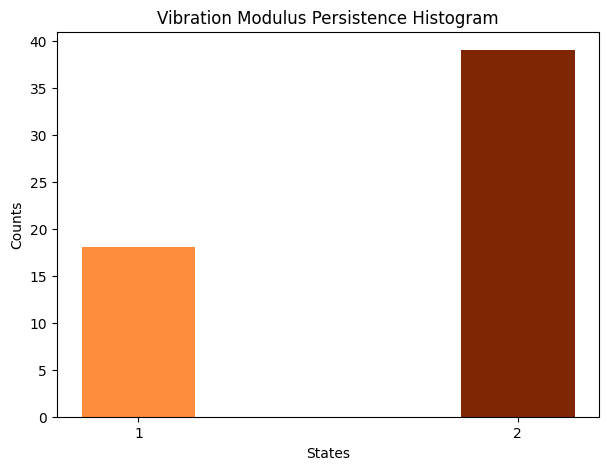

In [ ]:
cmap = plt.get_cmap('Oranges', n[0])
plt.figure(figsize=(7,5))

states,counts = np.unique(medianListR,return_counts=True)
plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
plt.xticks(states,np.int64(states))
plt.ylabel("Counts")
plt.xlabel("States")
plt.title("Vibration Modulus Persistence Histogram")
plt.savefig("../imagens_gerais/vibration_histogram.jpg")

In [ ]:
# Contagens das classes ao longo das inicializações
observed_counts = counts  # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 0.7368, p-valor: 0.6918
Não há evidências suficientes para afirmar que C ocorre mais que o esperado.


In [ ]:
for pump in pumpList:
   
    pumpData = totalData.loc[totalData["Well Run"]==pump].copy()

    # fig, axs =li.HMMPicture(
    #     pumpData,
    #     pump,
    #     props=[PCAHeaders,vibeHeader],
    #     states=["State Radius","State Mod"],
    #     numberOfStates=n,
    #     figsize=(40,15)
    #     )

    # fig.savefig("../imagensFinaisHMM/heatmap-"+pump+".png")
    # plt.close()
    onlineData = pumpData.loc[pumpData["Well_down"]==0]
    plt.figure(figsize=(10,10))
    plt.scatter(onlineData["Water Cut @ 20degC - 1 atm"],onlineData["Choke Closed"],c=onlineData["State Radius"],s=onlineData["Radius"])
    plt.xlabel("Water Cut @ 20degC - 1 atm")
    plt.ylabel("Choke Closed")
    plt.savefig("../choke_per_watercut/"+pump+".png")
    plt.close()


Text(0, 0.5, 'Choke Closed')

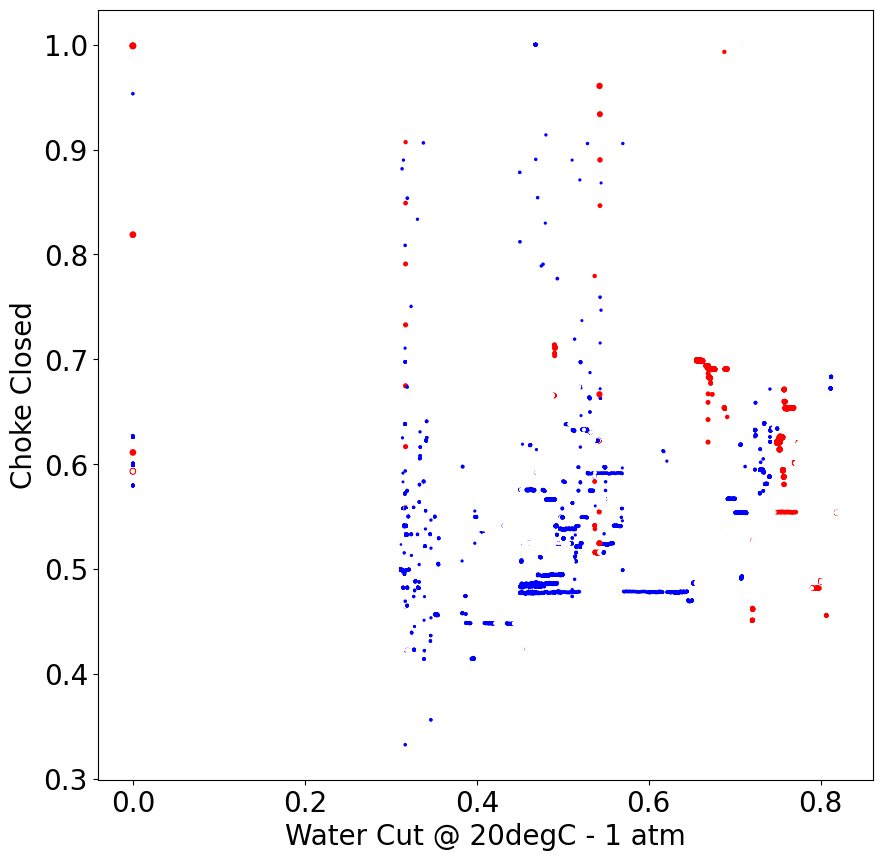

In [ ]:
onlineData = totalData.loc[(totalData["Well_down"]==0) & (totalData["Well Run"]==pumpList[50]) ]

x = onlineData["Water Cut @ 20degC - 1 atm"]#.apply(np.exp))
y = onlineData["Choke Closed"]#.apply(np.exp))

plt.figure(figsize=(10,10))
plt.scatter(x,y,c=onlineData["State Radius"],s=onlineData["Radius"],cmap='bwr')
plt.xlabel("Water Cut @ 20degC - 1 atm")
plt.ylabel("Choke Closed")
# plt.savefig("../choke_per_watercut/"+pump+".png")
# plt.close()

In [10]:
gmmTotal = li.GaussianMixtureFit(totalData[Headers].loc[totalData["Well_down"]==0].pow(2).pow(1/2),2,seed=mainSeed)

GMM BIC: 15699287.99525363


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from math import ceil, sqrt

def plot_gmm_marginals_square(gmm: GaussianMixture, X: np.ndarray, bins=50):
    n_features = X.shape[1]
    n_components = gmm.means_.shape[0]

    s = ceil(sqrt(n_features))
    fig, axes = plt.subplots(s, s, figsize=(5 * s, 4 * s))
    axes = axes.flatten()

    for i in range(n_features):
        ax = axes[i]
        x = X[:, i]
        ax.hist(x, bins=bins, density=True, alpha=0.5, label='Data hist')

        xmin, xmax = x.min(), x.max()
        x_grid = np.linspace(xmin, xmax, 1000)
        total_pdf = np.zeros_like(x_grid)

        for k in range(n_components):
            mean = gmm.means_[k, i]
            var = gmm.covariances_[k]
            if gmm.covariance_type == 'full':
                var = var[i, i]
            elif gmm.covariance_type == 'diag':
                var = var[i]
            elif gmm.covariance_type == 'spherical':
                var = var
            std = np.sqrt(var)

            weight = gmm.weights_[k]
            pdf_k = weight * norm.pdf(x_grid, loc=mean, scale=std)
            total_pdf += pdf_k
            ax.plot(x_grid, pdf_k, '--', label=f'Comp {k+1}')

        ax.plot(x_grid, total_pdf, '-', color='black', label='GMM Total')
        ax.set_title(f'Feature {i+1}')
        ax.legend()

    # Remove subplots extras se s² > n_features
    for j in range(n_features, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
    fig.savefig("../imagens_gerais/multiple_gmm.jpeg")
    


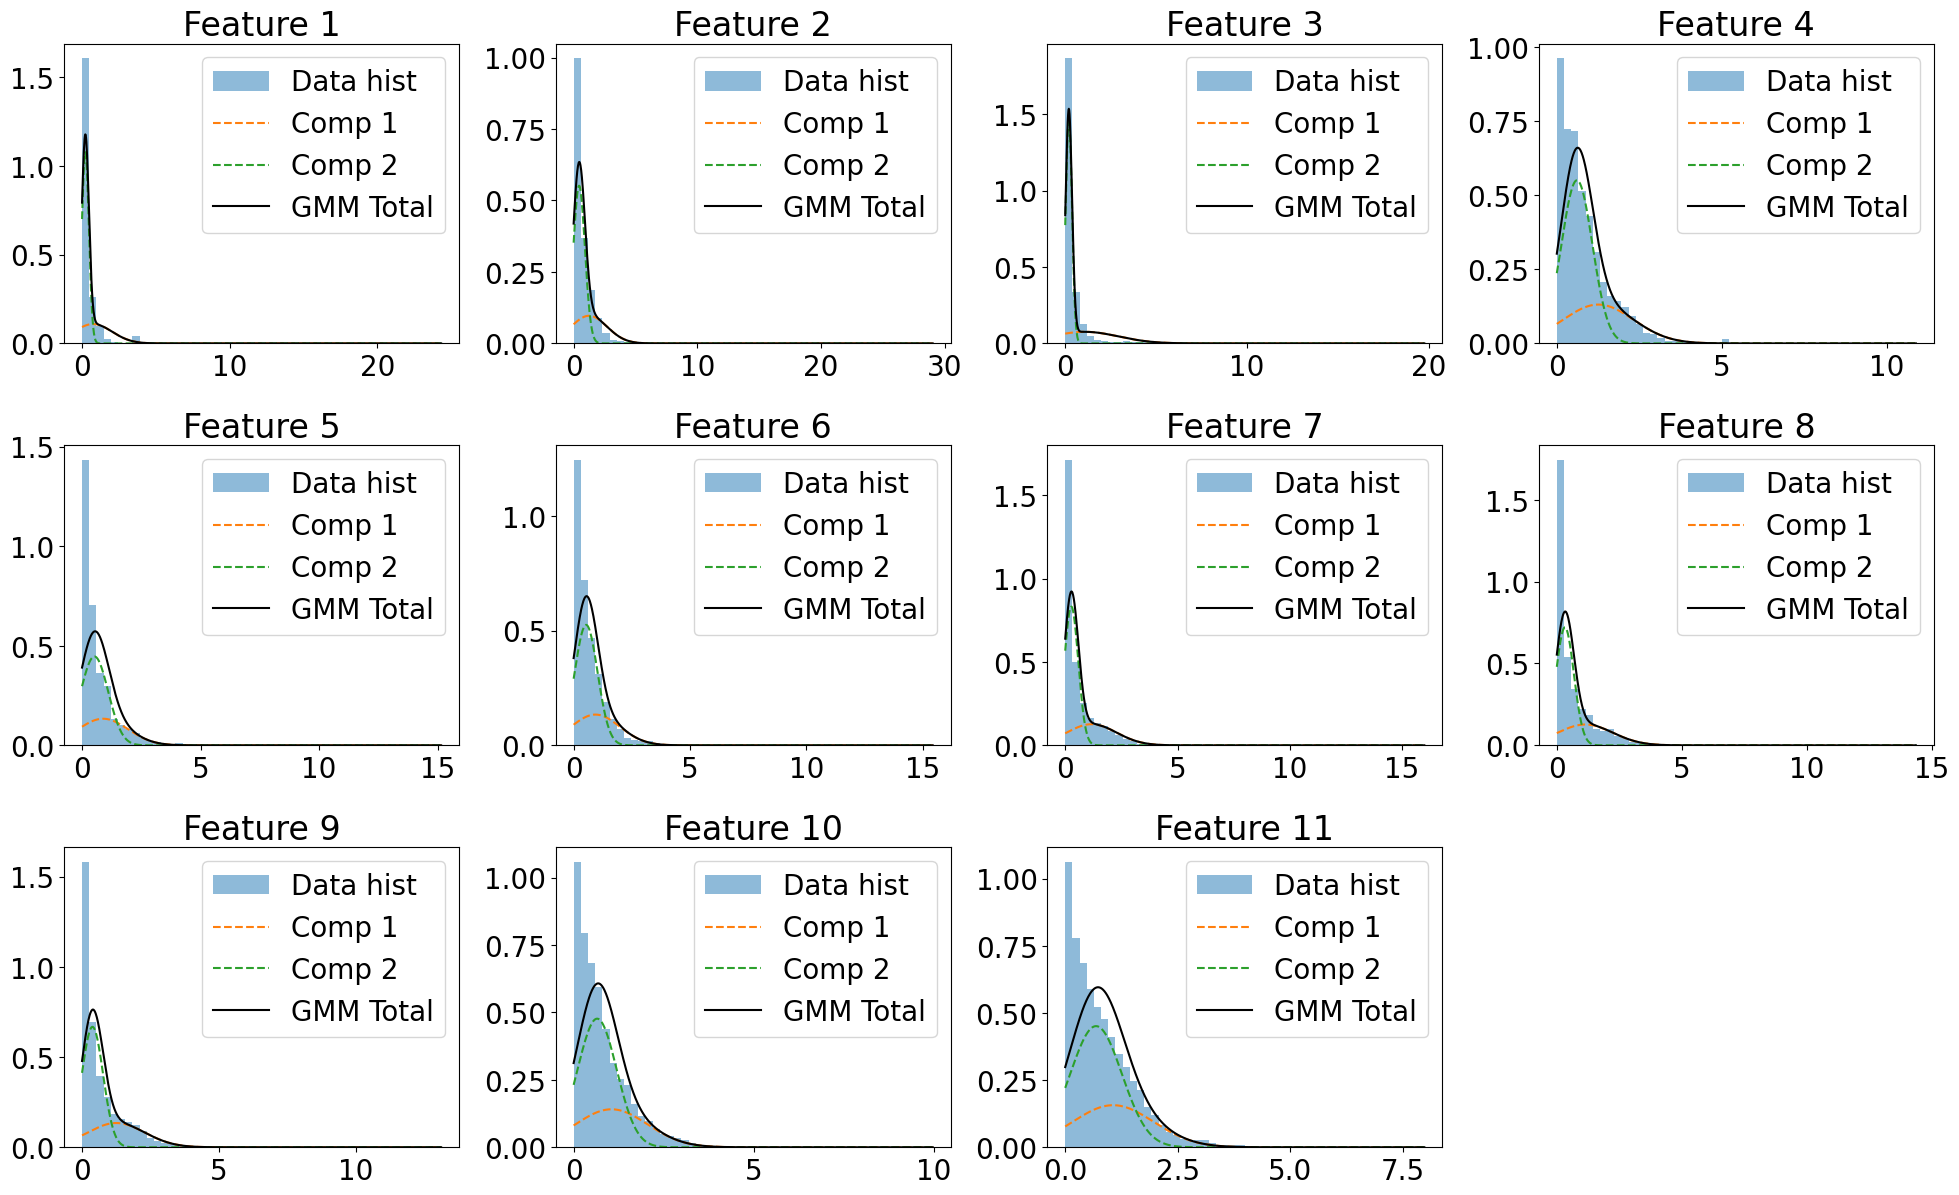

In [12]:
plot_gmm_marginals_square(gmmTotal,totalData[Headers].loc[totalData["Well_down"]==0].pow(2).pow(1/2).to_numpy())

In [14]:
gmmTotal.means_

array([[0.7459527 , 1.24911525, 1.06887362, 1.25843194, 0.88811401,
        0.93736199, 1.17629629, 1.13873787, 1.2483381 , 1.05060107,
        1.06375934],
       [0.22270961, 0.44360322, 0.19907446, 0.60982042, 0.52239067,
        0.53614449, 0.27150724, 0.32370102, 0.3800019 , 0.65186268,
        0.68421032]])

In [ ]:
# PCAData["Radius Category"] = pd.qcut(PCAData["Radius"],q=[0,.75,.95,1],labels=[1,2,3]).astype(int)
# PCAData["Radius Category"].hist()
# PCAData["Radius"].describe()

# modelCat = modelCat = hmm.CategoricalHMM(n_components=2,random_state=mainSeed)
# modelCat = li.HMMTrainer(X_train["Radius Category"],trainLength,modelCat)
# li.PostProcessing(modelCat, PCAData, modelData,"Radius Category", "State Cat", totalLength)
# print(modelCat.get_stationary_distribution())
# PCAData["State Cat"] = PCAData["State Cat"].map(li.StateConversion(modelCat.get_stationary_distribution(),2))


In [ ]:
# #modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],covar_type="diag")
# # pickle.dump(modelSq,open("MLmodels/modelSq.sav","wb"))

# modelSq = pickle.load(open("MLmodels/modelSq.sav","rb"))

# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))

# #modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],covar_type="full")
# # pickle.dump(modelVib,open("MLmodels/modelVib.sav","wb"))

# modelVib = pickle.load(open("MLmodels/modelVib.sav","rb"))
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))

# #modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],covar_type="full")
# #pickle.dump(modelTot,open("MLmodels/modelTot.sav","wb"))

# modelTot = pickle.load(open("MLmodels/modelTot.sav","rb"))
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))


# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM/"+pump)
#     plt.close()

In [ ]:
# numberOfDays = 7

# stats = pd.DataFrame(columns=["State Vib", "State Gaussian","State Tot"])

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump]
#     if pumpData.loc[pumpData["Failure"]==1].empty != True:
#         failure = pumpData.loc[pumpData["Failure"]==1].index[0]
#         indexRef = pumpData.index[0]
#         selectedData = pumpData.iloc[failure-indexRef-numberOfDays*24:]

#         stats = pd.concat([stats, 
#                        selectedData.loc[selectedData["Well_down"]==0][["State Vib", "State Gaussian","State Tot"]]])

    

In [ ]:
# stats.reset_index(inplace=True,drop=True)
# stats = stats.infer_objects()
# stats.drop(labels=0,inplace=True)
# stats.hist()


In [ ]:
# modelSq = li.HiddenMarkovModel(X_train["Transformed Radius"], trainLength, mainSeed, n[0],algorithm="map")
# li.PostProcessing(modelSq, PCAData, modelData,"Transformed Radius", "State Gaussian", totalLength)
# print(modelSq.get_stationary_distribution())
# PCAData["State Gaussian"] = PCAData["State Gaussian"].map(li.StateConversion(modelSq.get_stationary_distribution(),n[0]))
# pickle.dump(modelSq,open("modelSq_map.sav","wb"))

# modelVib = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY"]], trainLength, mainSeed, n[1],algorithm="map")
# li.PostProcessing(modelVib, PCAData, modelData,["VibNormX","VibNormY"], "State Vib", totalLength)
# print(modelVib.get_stationary_distribution())
# PCAData["State Vib"] = PCAData["State Vib"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))
# pickle.dump(modelVib,open("modelVib_map.sav","wb"))

# modelTot = li.HiddenMarkovModel(X_train[["VibNormX","VibNormY","Transformed Radius"]], trainLength, mainSeed, n[2],algorithm="map")
# li.PostProcessing(modelTot, PCAData, modelData,["VibNormX","VibNormY","Transformed Radius"], "State Tot", totalLength)
# print(modelTot.get_stationary_distribution())
# PCAData["State Tot"] = PCAData["State Tot"].map(li.StateConversion(modelTot.get_stationary_distribution(),n[2]))
# pickle.dump(modelTot,open("modelTot.sav","wb"))

# for pump in pumpList:
#     pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
#     fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)
#     fig.savefig("../imagensHMM_map/"+pump)
#     plt.close()

In [ ]:
# pump = pumpList[0]

# pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
# fig,axs = li.HMMPicture(pumpData,pump,PCAHeaders,n)